In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
sys.path.append('../')
import pandas as pd
import numpy as np

from Utils.LSTM_net import CNN_LSTM_Model
from Utils.train import  train, eval, data_train, patient_stratify_split
from Utils.download import read_raws
import torch
from sklearn.metrics import confusion_matrix
from seaborn import heatmap
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(0)

In [2]:
channels=['Fp1', 'Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']
channels_dif=['Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F7-T3', 'T3-T5', 'T5-O1', 'F8-T4', 'T4-T6', 'T6-O2', 'Fz-Cz', 'Cz-Pz']
path_demographic="../d/data_patients.csv"

### Data base demographic
df_demog=pd.read_csv(path_demographic, sep="," )
df_demog["numeric_outcome"]=df_demog["Outcome"].map({"Good": 1, "Poor": 0})
df_demog.reset_index(drop=True, inplace=True)
df_demog.head()

,Id_Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC,numeric_outcome
0,284,A,53.0,Male,NaN,True,True,33.0,Good,1,1
1,286,F,85.0,Female,7.0,False,False,NaN,Good,1,1
2,296,A,48.0,Male,NaN,True,True,36.0,Good,1,1
3,299,A,45.0,Male,NaN,True,True,33.0,Good,1,1
4,303,D,51.0,Male,24.0,True,True,33.0,Good,1,1


In [6]:
times=[([32, 36, 40, 44],channels)]

In [4]:
def initial_data( time:list, channels:list, path_raw: str =f"../raw_tif/t180_h", time_taken: int =180, del_files: bool =True,
               wind_size: int =200, overlap: int =64, df_demog: pd.DataFrame =df_demog, partition: bool =False):

    """Cargar y preprocesar datos EEG para entrenamiento.
    
    Parámetros:
    - time: lista de horas (ej. [32,36,40,44]) cuyos directorios se cargarán.
    - channels: lista de canales a usar para el entrenamiento.
    - path_raw: prefijo de ruta donde están las carpetas por hora.
    - time_taken: duración en segundos usada por read_raws.
    - del_files: si True borra archivos temporales tras leer.
    - wind_size: tamaño de ventana (muestras) para segmentación.
    - overlap: solapamiento entre ventanas.
    - df_demog: DataFrame demográfico con `Outcome` y `Id_Patient`.
    - partition: si True devuelve los índices de pacientes y tensores crudos en lugar de conjuntos train/val.
    
    Retorna:
    Si partition es False: (X_train, y_train, X_val, y_val, num_classes, n_patients).
    Si partition es True: (patients_train, patients_val, X_eeg, Y_eeg).
    """
    Raws=[]
    Patients= []
    Hours=[]

    for t in time:
        path_files=path_raw+str(t)+"/"
        print(path_files)
        raw_list, patients= read_raws(path_files=path_files, time_taken= time_taken, del_files=del_files)
        Raws+=raw_list
        Patients+=patients
        Hours+=[t]*len(raw_list)
        del raw_list, patients

    wind_size=wind_size
    overlap=overlap
    X_eeg, demograp_data = data_train(raw_list=Raws, df_demog=df_demog, wind_size=wind_size,
                                    over_lap=overlap, patients=Patients, channels=channels)
    
    
    X_eeg= torch.stack(X_eeg, dim=0)
    Y_eeg= torch.tensor(np.array(demograp_data["numeric_outcome"],dtype=float)).long()
    demograp_data.set_index("Id_Patient",inplace=True)
    demograp_data["Hour_taken"]=Hours
    demograp_data["indices"]=range(len(demograp_data))
    num_classes=len(Y_eeg.unique())
    patients_train, patients_val= patient_stratify_split(demograp_data, train_size=0.75)
    
    if partition:
        return patients_train, patients_val, X_eeg, Y_eeg
    
    else:
        train_demograp= demograp_data.loc[patients_train]
        train_demograp["indices"]= range(len(train_demograp))
        val_demograp= demograp_data.loc[patients_val]
        val_demograp["indices"]= range(len(val_demograp))

        train_ind= train_demograp["indices"].values
        X_train, y_train= X_eeg[train_ind], Y_eeg[train_ind]
        val_ind= val_demograp["indices"].values
        X_val, y_val= X_eeg[val_ind], Y_eeg[val_ind]
        n_paients=len(pd.unique(Patients))
        
        del Raws, Hours, X_eeg, Y_eeg
        return X_train, y_train, X_val, y_val, num_classes, n_paients

In [ ]:
results={}
for time , group, s_gorup in times:

    Raws=[]
    Patients= []
    Hours=[]

    for t in time:
        path_files=f"../data_train/t180_h{t}/"
        print(f"/t180_h{t}/")
        raw_list, patients= read_raws(path_files=path_files, time_taken=180, del_files=True)
        Raws+=raw_list
        Patients+=patients
        Hours+=[t]*len(raw_list)
        del raw_list, patients

    wind_size=200
    overlap=64
    X_eeg, demograp_data = data_train(raw_list=Raws, df_demog=df_demog, wind_size=wind_size,
                                    over_lap=overlap, patients=Patients, channels=group)
    
    
    X_eeg= torch.stack(X_eeg, dim=0)
    Y_eeg= torch.tensor(np.array(demograp_data["numeric_outcome"],dtype=float)).long()
    print(X_eeg.shape)
    demograp_data.set_index("Id_Patient",inplace=True)
    demograp_data["Hour_taken"]=Hours
    demograp_data["indices"]=range(len(demograp_data))
    num_classes=len(Y_eeg.unique())
    patients_train, patients_val= patient_stratify_split(demograp_data, train_size=0.75)
    train_demograp= demograp_data.loc[patients_train]
    train_demograp["indices"]= range(len(train_demograp))
    val_demograp= demograp_data.loc[patients_val]
    val_demograp["indices"]= range(len(val_demograp))

    train_ind= train_demograp["indices"].values
    X_train, y_train= X_eeg[train_ind], Y_eeg[train_ind]
    val_ind= val_demograp["indices"].values
    X_val, y_val= X_eeg[val_ind], Y_eeg[val_ind]
    n_paients=print(len(pd.unique(Patients)))
    del Raws, Hours, X_eeg, Y_eeg

    model_LSTM=CNN_LSTM_Model(num_classes=num_classes, cnn_out=64, lstm_hidden=64, lstm_layers=2, conv_2d_layer=64,
                            dropout_layer=0.2, dropout_lstm=0.2).to(device)
    model_LSTM, Cumulate_scores, Cumulate_loss = train(model=model_LSTM, X_train=X_train, 
                                                    demograp_train_data=train_demograp,
                                                    y_train=y_train, patients=patients_train, n_splits=5, 
                                                    batch_size=24, epochs=100, device=device,lr=5.5e-4)
    
    name_path="h_"+"_".join([str(i) for i in time])+s_gorup
    os.makedirs(f"../Model/{name_path}")
    metrics= eval(model=model_LSTM, X_test=X_val, y_test=y_val, S_labels=["Poor", "Good"], model_name="LSTM",
        Cumulate_loss=Cumulate_loss, Cumulate_scores=Cumulate_scores, 
        path_confusion=f"../Model/{name_path}/{name_path}confusion",path_f1score=f"../Model/{name_path}/{name_path}auc_score")
    
    results[name_path]={"n_patierns":n_paients, "model":model_LSTM, "loss": Cumulate_loss, "scores": Cumulate_scores, "metrics":metrics,
                        "esquema":group}

    torch.save(model_LSTM.state_dict(), f"../Model/{name_path}/model_lstm_{name_path}.pt")
    del X_train,y_train, X_val, y_val, model_LSTM, Cumulate_loss, Cumulate_scores

with open('../Model/results.pkl', 'wb') as archivo:
    pickle.dump(results, archivo)

Validacion

In [9]:
patients_train, patients_val, X_eeg, Y_eeg =initial_data(time=[32], channels=channels_dif, partition=True)

../raw_tif/t180_h32/
Opening raw data file ../raw_tif/t180_h32/patient_0284.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0286.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0299.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0303.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0306.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0312.fif...
    Range : 

../raw_tif/t180_h32/
Opening raw data file ../raw_tif/t180_h32/patient_0284.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0286.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0299.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0303.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0306.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file ../raw_tif/t180_h32/patient_0312.fif...
    Range : 

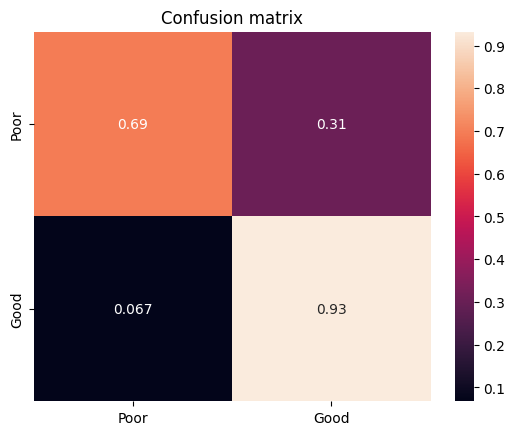

Exactitud: 0.7917620137299771
Exhaustividad: 0.7917620137299771
Precisión: 0.8316168916079018
f1_score: 0.7927858862440189


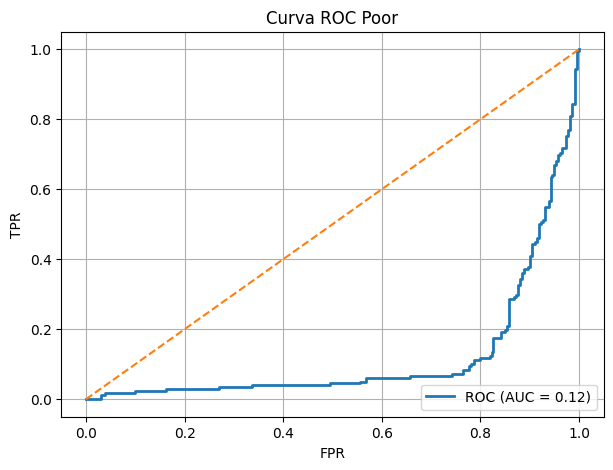

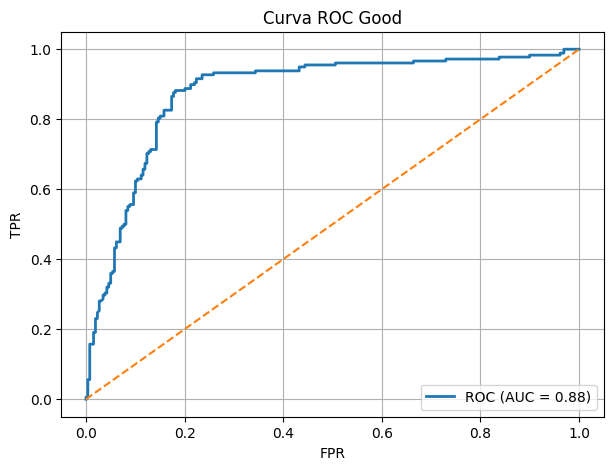

0.8785519066417944


In [ ]:
_, _, X_val, y_val, num_classes, n_paients=initial_data(time=[32,36,40,44], channels=channels)
model_LSTM=CNN_LSTM_Model(num_classes=num_classes, cnn_out=64, lstm_hidden=64, lstm_layers=2, conv_2d_layer=64,
                            dropout_layer=0.2, dropout_lstm=0.2).to(device)

model_LSTM.load_state_dict(torch.load("C:/Users\THIN\OneDrive - Escuela Tecnologica Instituto Tecnico Central\Proyecto_cerebro\MAPI\Results\h_32_36_40_44_win_Good\model_lstm_h_32_36_40_44.pt"))

metrics= eval(model=model_LSTM, X_test=X_val, y_test=y_val, S_labels=["Poor", "Good"], model_name="Confusion matrix",
        path_confusion=None,path_f1score=None, save_fig=False, normalize_conf_matr="true")
# del model_LSTM
print(metrics[-4])

In [6]:
from torch.utils.data import Dataset, DataLoader

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Best threshold: 0.9643
Maxima index: 0.7006


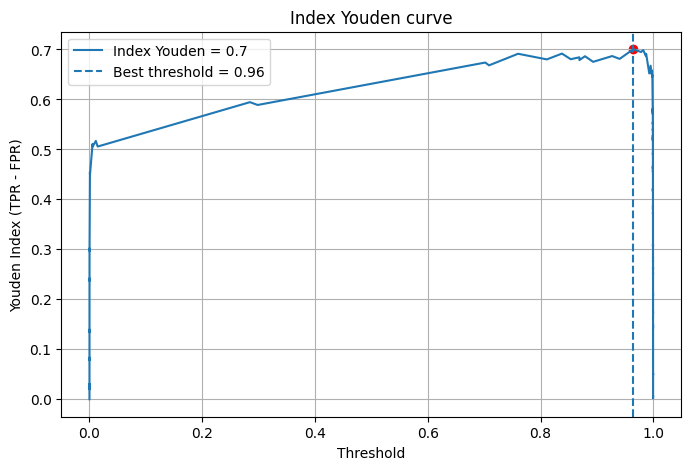

In [7]:
import matplotlib.pyplot as plt
idx=np.argsort(metrics[-1])
thresholds=metrics[-1]
tpr=metrics[-2]
fpr=metrics[-3]

# Índice de Youden
youden_index = tpr - fpr

# Mejor umbral
best_idx = np.argmax(youden_index)
best_threshold = thresholds[best_idx]
best_youden = youden_index[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Maxima index: {best_youden:.4f}")

# Graficar
plt.figure(figsize=(8,5))
plt.plot(thresholds[idx], youden_index[idx], label=f"Index Youden = {round(best_youden,2)}")

# Marcar el mejor punto
plt.scatter(best_threshold, best_youden, color='red')
plt.axvline(best_threshold, linestyle='--', label=f"Best threshold = {best_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Youden Index (TPR - FPR)")
plt.title("Index Youden curve")
plt.legend()
plt.grid()
plt.savefig("C:/Users\THIN\OneDrive - Escuela Tecnologica Instituto Tecnico Central\Proyecto_cerebro\MAPI\Results\h_32_36_40_44_dif\Youden_indx.jpg", dpi=200)
plt.show()

In [8]:
# Dataset
data_test = EEGDataset(X_val, y_val)
test_loader = DataLoader(data_test, batch_size=20, shuffle=False)

# Modelo en CPU y modo evaluación
model_LSTM.cpu()
model_LSTM.eval()

# 👉 threshold obtenido previamente (ej. con Youden)
threshold = best_threshold  # <-- reemplaza con tu valor

y_score = []
y_pred = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        X_batch = X_batch.float().cpu()
        y_batch = y_batch.cpu()

        logits = model_LSTM(X_batch)

        # Probabilidad de la clase positiva (clase 1)
        probs = torch.softmax(logits, dim=1)[:, 1]

        # Predicción usando threshold
        preds = (probs >= threshold).long()

        y_score.append(probs)
        y_pred.append(preds)
        y_true.append(y_batch)
        
        del X_batch

y_score=torch.cat(y_score)
y_pred=torch.cat(y_pred)
y_test_cpu=torch.cat(y_true)

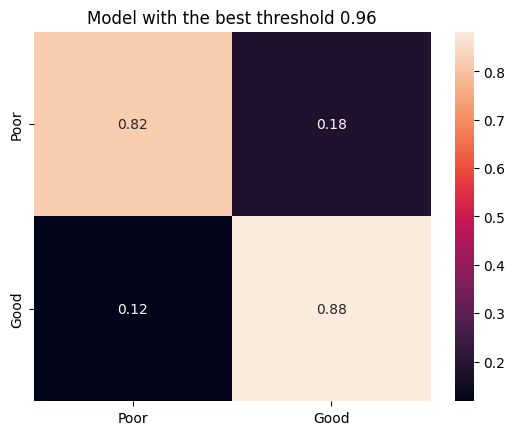

In [10]:
save_fig=False
m_conf = confusion_matrix(y_test_cpu, y_pred,normalize="true")
plt.figure()
heatmap(m_conf, annot=True, fmt=".2g",
        xticklabels=["Poor", "Good"],
        yticklabels=["Poor", "Good"])


plt.title(f"Model with the best threshold {round(best_threshold,2)}")
if save_fig:
    plt.savefig("C:/Users\THIN\OneDrive - Escuela Tecnologica Instituto Tecnico Central\Proyecto_cerebro\MAPI\Results\h_32_36_40_44_dif/best_model.jpg", dpi=200)
plt.show()